# Ejercicio 4

In [9]:
import pyvo as vo
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as sp
import numpy as np

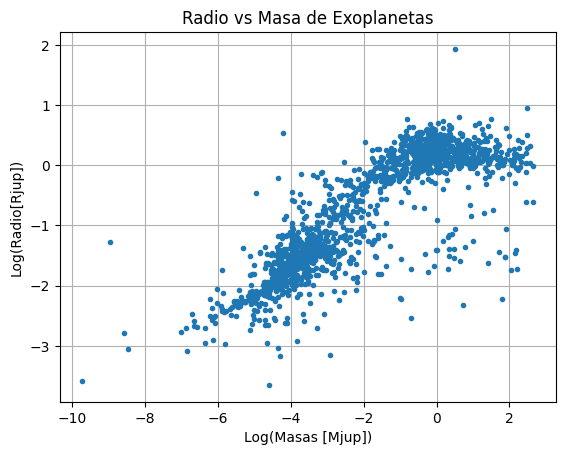

In [10]:
# seleccionamos el servidor a partir del cual vamos a buscar los datos
service = vo.dal.TAPService("http://voparis-tap-planeto.obspm.fr/tap")


query = "SELECT granule_uid,radius, mass FROM exoplanet.epn_core WHERE mass < 15 AND period>0 AND star_distance>0" 
results = service.search(query)
table = results.to_table()
df = table.to_pandas()
df.set_index('granule_uid',inplace = True)
df.head()

# Nos aseguramos de eliminar las filas con datos faltantes en las columnas 'radius' y 'mass'
df = df.dropna(subset=['radius', 'mass']) 

#plot

plt.plot(np.log(df['mass']),np.log(df['radius']),'o', markersize = 3) 

plt.xlabel('Log(Masas [Mjup])')
plt.ylabel('Log(Radio[Rjup])')
plt.title('Radio vs Masa de Exoplanetas')
plt.grid()
plt.show()

Con toda la caradurez y a lo hubble, aunque esta vez con mas puntos, le vamos a ajustar una lineal. 

El ajuste es: log(R) = 0.38 * log(M) + -0.05


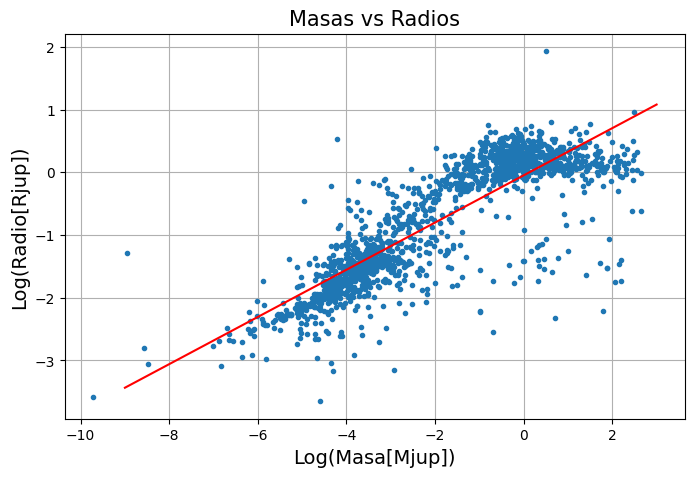

In [12]:
x = df['mass']
y = df['radius']

ajuste = np.polyfit(np.log(df['mass']),np.log(df['radius']),1) 

#plot del ajuste

plt.figure(figsize=(8, 5))
plt.plot(np.log(df['mass']),np.log(df['radius']),'o',ms=3)
plt.title('Masas vs Radios',fontsize=15)
plt.xlabel("Log(Masa[Mjup])",fontsize=14);plt.ylabel("Log(Radio[Rjup])",fontsize=14)
t = np.linspace(-9,3,50)
plt.plot(t, ajuste[0]*t+ajuste[1],color = 'r')
plt.grid()

print(f'El ajuste es: log(R) = {ajuste[0]:.2f} * log(M) + {ajuste[1]:.2f}')

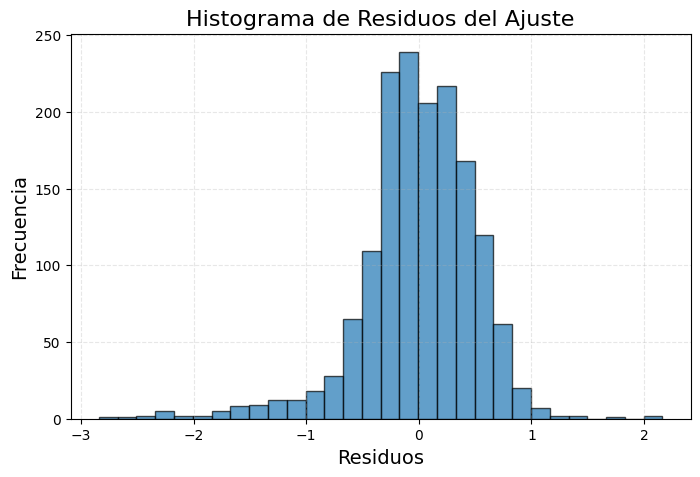

In [13]:
#Para estudiar si fue un buen ajuste, podemos calcular los residuos
residuos = np.log(df['radius']) - (ajuste[0]*np.log(df['mass']) + ajuste[1])
plt.figure(figsize=(8, 5))
plt.hist(residuos, bins=30, edgecolor='black', alpha=0.7)
plt.title('Histograma de Residuos del Ajuste', fontsize=16)
plt.xlabel('Residuos', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)
plt.grid(True, alpha=0.3, linestyle='--')
plt.show()  